In [1]:
# ─── Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# ─── Load All 9 Tables ─────────────────────────────────────
# Each CSV is a separate business entity
# We load them individually first, understand each one,
# then merge strategically — not all at once blindly

path = '../data/raw/'

orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items  = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
geolocation  = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category     = pd.read_csv(path + 'product_category_name_translation.csv')

# Summary of all tables
tables = {
    'orders': orders, 'customers': customers,
    'order_items': order_items, 'payments': payments,
    'reviews': reviews, 'products': products,
    'sellers': sellers, 'geolocation': geolocation,
    'category': category
}

print("=" * 45)
print(f"{'Table':<20} {'Rows':>10} {'Columns':>10}")
print("=" * 45)
for name, df in tables.items():
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>10}")
print("=" * 45)

Table                      Rows    Columns
orders                   99,441          8
customers                99,441          5
order_items             112,650          7
payments                103,886          5
reviews                  99,224          7
products                 32,951          9
sellers                   3,095          4
geolocation           1,000,163          5
category                     71          2


In [3]:
# ─── Orders Table — The Heart of the Dataset ───────────────
# orders is the central table — everything connects to it
# via order_id. Understanding it first is critical.

print("=== ORDERS TABLE ===")
print(f"Shape: {orders.shape}")
print(f"\nColumns:\n{orders.columns.tolist()}")
print(f"\nData Types:\n{orders.dtypes}")
print(f"\nSample:")
orders.head()

=== ORDERS TABLE ===
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
print(orders['order_status'].unique())

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str


Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Percentages:
order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: count, dtype: float64


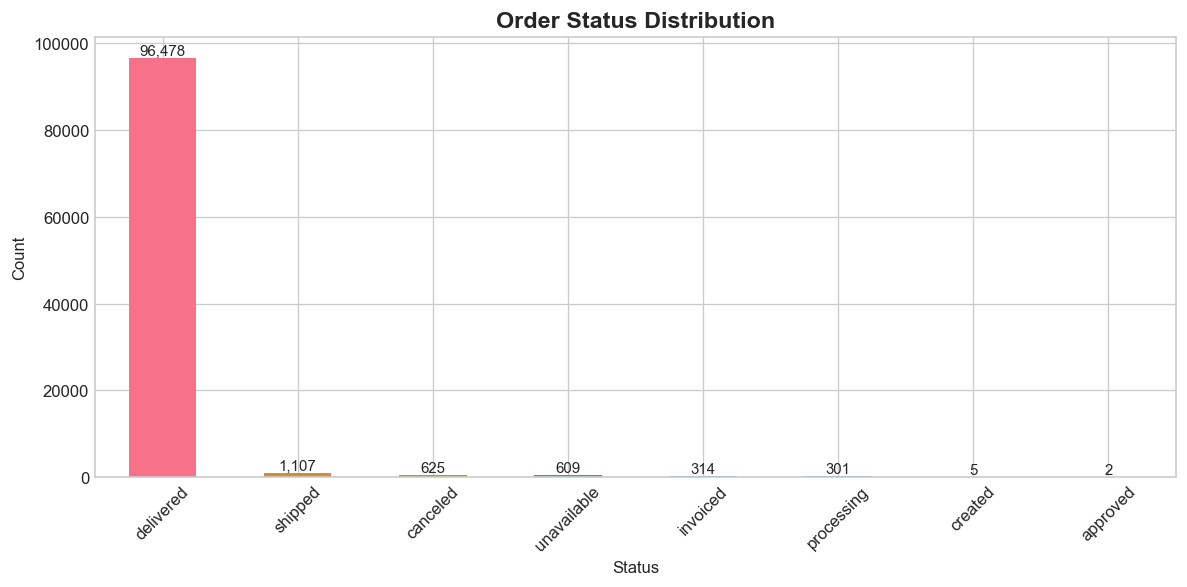

In [6]:
# ─── Order Status — This Becomes Our Target Variable ───────
# order_status tells us the outcome of each order
# We will define our binary target:
# 1 = canceled
# 0 = delivered (successfully completed)
# All other statuses will be investigated

print("Order Status Distribution:")
status_counts = orders['order_status'].value_counts()
print(status_counts)
print(f"\nPercentages:")
print((status_counts / len(orders) * 100).round(2))

# Plot
plt.figure(figsize=(10, 5))
ax = status_counts.plot(kind='bar', color=sns.color_palette('husl', len(status_counts)))
plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/order_status_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ─── Class Imbalance Check ─────────────────────────────────
# Binary classification: canceled vs delivered
# Cancellations are rare — this is expected in real business data
# Knowing the imbalance ratio upfront tells us we'll need
# SMOTE or class_weight adjustments in modelling

canceled  = orders[orders['order_status'] == 'canceled'].shape[0]
delivered = orders[orders['order_status'] == 'delivered'].shape[0]
total     = canceled + delivered

print(f"Canceled orders  : {canceled:,} ({canceled/total*100:.2f}%)")
print(f"Delivered orders : {delivered:,} ({delivered/total*100:.2f}%)")
print(f"Imbalance ratio  : 1 : {delivered//canceled}")
print(f"\nThis is a {'severe' if canceled/total < 0.05 else 'moderate'} class imbalance.")
print("We will handle this with SMOTE in the modelling phase.")

Canceled orders  : 625 (0.64%)
Delivered orders : 96,478 (99.36%)
Imbalance ratio  : 1 : 154

This is a severe class imbalance.
We will handle this with SMOTE in the modelling phase.


In [8]:
# ─── Profile Each Table ────────────────────────────────────
# For each table: shape, missing values, key columns
# This is the foundation of our merge strategy

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{'='*50}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    if len(missing) > 0:
        print(f"Missing values:")
        for col, count in missing.items():
            print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")
    else:
        print("Missing values: None")


TABLE: ORDERS
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Missing values:
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)

TABLE: CUSTOMERS
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Missing values: None

TABLE: ORDER_ITEMS
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Missing values: None

TABLE: PAYMENTS
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Missing values: None

TABLE: REVIEWS
Shape: (99224, 7)
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_mes

In [9]:
# ─── Join Key Analysis ─────────────────────────────────────
# Before merging, verify join keys are consistent
# A mismatch here causes rows to silently disappear

print("=== JOIN KEY ANALYSIS ===\n")

print(f"orders.order_id unique       : {orders['order_id'].nunique():,}")
print(f"order_items.order_id unique  : {order_items['order_id'].nunique():,}")
print(f"payments.order_id unique     : {payments['order_id'].nunique():,}")
print(f"reviews.order_id unique      : {reviews['order_id'].nunique():,}")

print(f"\norders.customer_id unique    : {orders['customer_id'].nunique():,}")
print(f"customers.customer_id unique : {customers['customer_id'].nunique():,}")

print(f"\norder_items.product_id unique: {order_items['product_id'].nunique():,}")
print(f"products.product_id unique   : {products['product_id'].nunique():,}")

print(f"\norder_items.seller_id unique : {order_items['seller_id'].nunique():,}")
print(f"sellers.seller_id unique     : {sellers['seller_id'].nunique():,}")

=== JOIN KEY ANALYSIS ===

orders.order_id unique       : 99,441
order_items.order_id unique  : 98,666
payments.order_id unique     : 99,440
reviews.order_id unique      : 98,673

orders.customer_id unique    : 99,441
customers.customer_id unique : 99,441

order_items.product_id unique: 32,951
products.product_id unique   : 32,951

order_items.seller_id unique : 3,095
sellers.seller_id unique     : 3,095


In [10]:
# ─── Date Columns Analysis ─────────────────────────────────
# Orders table has 7 date columns
# These will be engineered into powerful features:
# - Days between purchase and delivery
# - Time of day / day of week patterns
# - Estimated vs actual delivery gap

date_cols = [col for col in orders.columns if 'date' in col or 'timestamp' in col]
print(f"Date columns in orders: {date_cols}")

# Convert to datetime
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f"\nDate range:")
print(f"Earliest order: {orders['order_purchase_timestamp'].min()}")
print(f"Latest order  : {orders['order_purchase_timestamp'].max()}")
print(f"Total period  : {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} days")

Date columns in orders: ['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Date range:
Earliest order: 2016-09-04 21:15:19
Latest order  : 2018-10-17 17:30:18
Total period  : 772 days


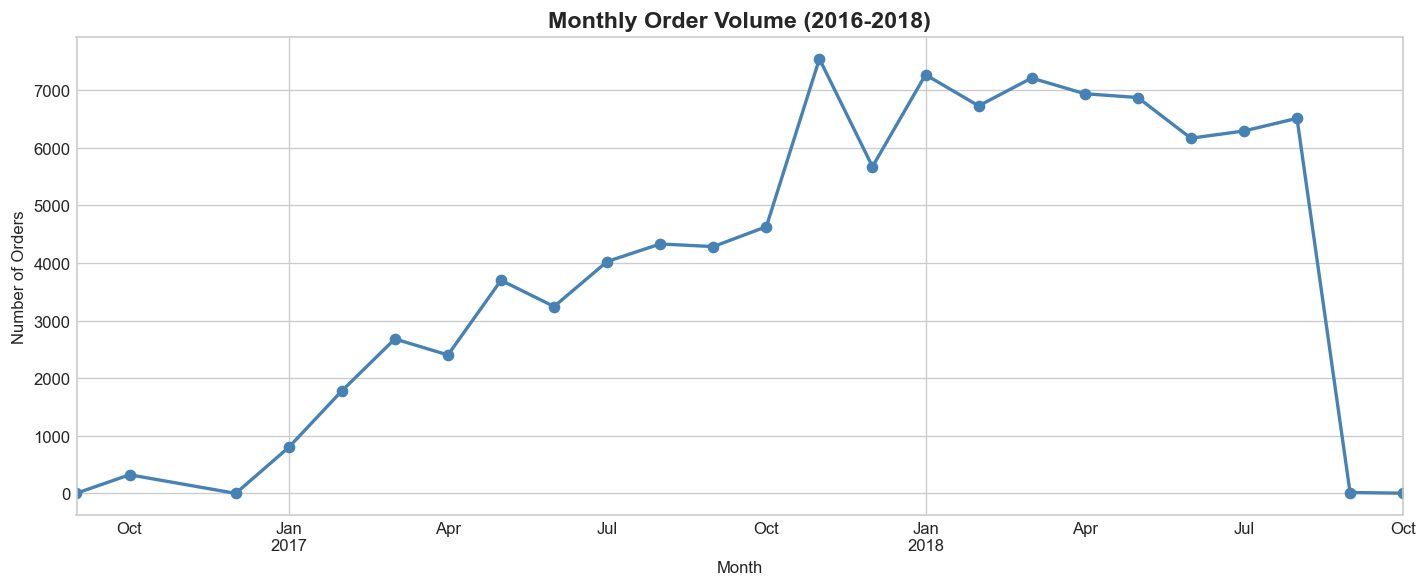

In [13]:
# ─── Orders Over Time ──────────────────────────────────────
# Visualise growth trend and seasonality
# Also helps spot any data gaps or anomalies in the timeline

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('year_month').size()

plt.figure(figsize=(12, 5))
monthly.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Order Volume (2016-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../reports/orders_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

=== PAYMENTS TABLE ===

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Payment value stats:
count   103886.00
mean       154.10
std        217.49
min          0.00
25%         56.79
50%        100.00
75%        171.84
max      13664.08
Name: payment_value, dtype: float64


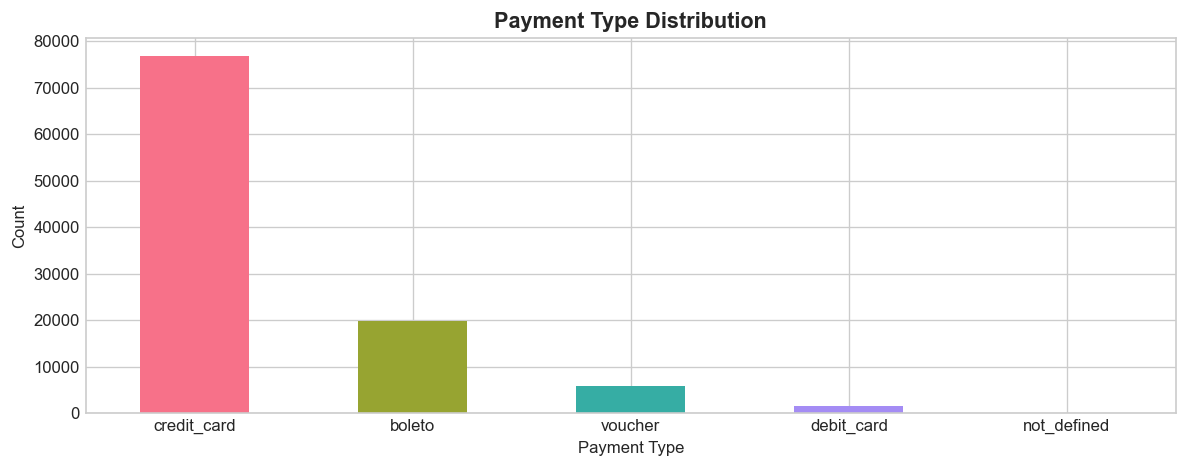

In [14]:
# ─── Payment Analysis ──────────────────────────────────────
# Payment type and value are strong predictors of cancellation
# High value orders, certain payment types may correlate with cancellations

print("=== PAYMENTS TABLE ===")
print(f"\nPayment type distribution:")
print(payments['payment_type'].value_counts())

print(f"\nPayment value stats:")
print(payments['payment_value'].describe())

# Plot payment types
plt.figure(figsize=(10, 4))
payments['payment_type'].value_counts().plot(kind='bar', color=sns.color_palette('husl', 4))
plt.title('Payment Type Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/payment_types.png', dpi=120, bbox_inches='tight')
plt.show()

=== REVIEWS TABLE ===
Shape: (99224, 7)

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


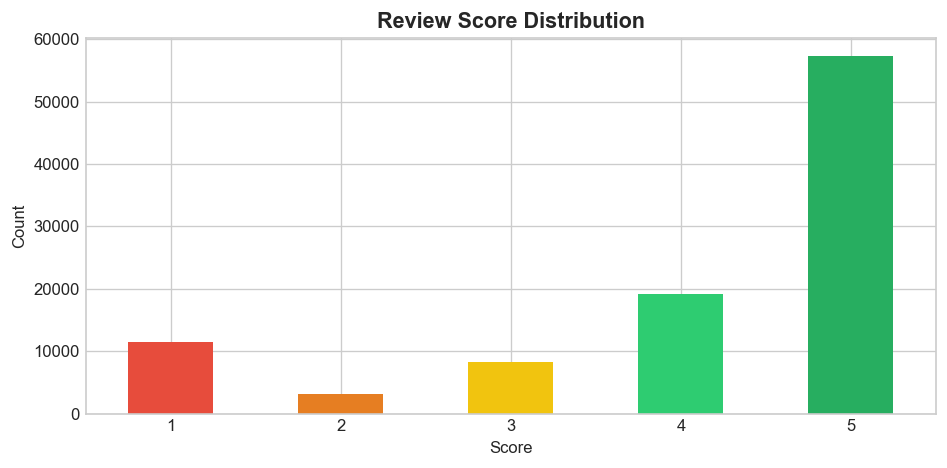

In [15]:
# ─── Review Score Analysis ─────────────────────────────────
# Review scores after delivery reveal customer satisfaction
# Low scores may correlate with problematic orders
# Note: cancelled orders may not have reviews at all

print("=== REVIEWS TABLE ===")
print(f"Shape: {reviews.shape}")
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#27AE60']
)
plt.title('Review Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/review_scores.png', dpi=120, bbox_inches='tight')
plt.show()

Top 10 states by customer count:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


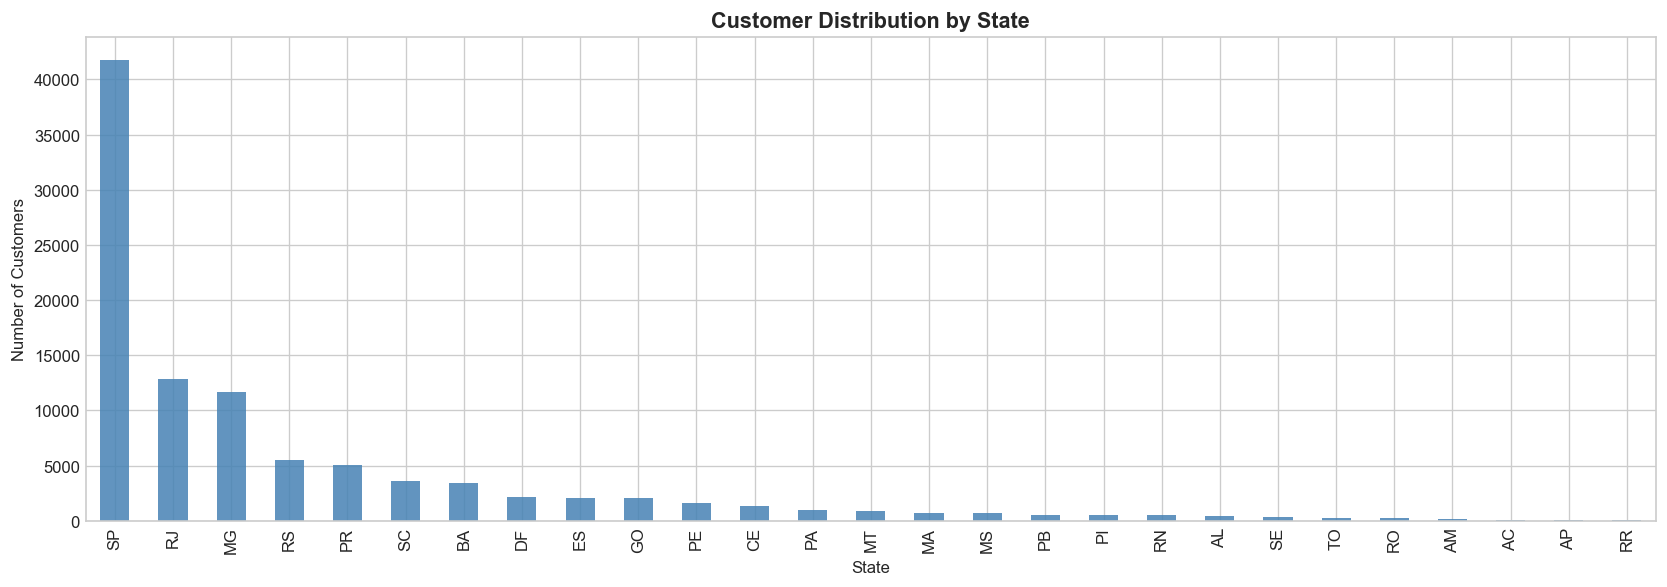

In [16]:
# ─── Geographic Distribution ───────────────────────────────
# Brazil has 27 states — cancellation patterns may vary by region
# This will feed into geospatial analysis in Day 7

customer_state = customers['customer_state'].value_counts()
print("Top 10 states by customer count:")
print(customer_state.head(10))

plt.figure(figsize=(14, 5))
customer_state.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Customer Distribution by State', fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/customer_by_state.png', dpi=120, bbox_inches='tight')
plt.show()